## Disease Prediction using GaussianNB, DecisionTreeClassifier, RandomForestClassifier in Sklearn

### 1. Importing Libraries

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

### 2. Loading Dataset

In [4]:
!wget https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/40-Disease%20Prediction/improved_disease_dataset.csv

--2026-03-24 15:20:10--  https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/40-Disease%20Prediction/improved_disease_dataset.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 70548 (69K) [text/plain]
Saving to: ‘improved_disease_dataset.csv’

improved_disease_da 100%[===================>]  68.89K  --.-KB/s    in 0.02s   

2026-03-24 15:20:11 (3.68 MB/s) - ‘improved_disease_dataset.csv’ saved [70548/70548]



In [6]:
df = pd.read_csv('improved_disease_dataset.csv')
df.head()

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes,disease
0,1,0,1,0,1,0,0,1,1,0,Paralysis (brain hemorrhage)
1,0,0,1,0,0,0,1,1,0,0,Paralysis (brain hemorrhage)
2,0,0,1,0,1,0,1,1,0,0,Paralysis (brain hemorrhage)
3,0,0,1,1,1,0,1,1,1,1,Paralysis (brain hemorrhage)
4,1,0,1,0,1,0,0,0,1,1,Paralysis (brain hemorrhage)


### 3. Data Preprocessing

1. Exploratory Data Analysis

In [7]:
df.shape

(2000, 11)

In [8]:
df.describe()

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,0.328000,0.413000,0.378500,0.526000,0.365500,0.450500,0.387000,0.55500,0.456000,0.449000
std,0.469602,0.492496,0.485134,0.499448,0.481691,0.497668,0.487185,0.49709,0.498185,0.497517
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   fever        2000 non-null   int64 
 1   headache     2000 non-null   int64 
 2   nausea       2000 non-null   int64 
 3   vomiting     2000 non-null   int64 
 4   fatigue      2000 non-null   int64 
 5   joint_pain   2000 non-null   int64 
 6   skin_rash    2000 non-null   int64 
 7   cough        2000 non-null   int64 
 8   weight_loss  2000 non-null   int64 
 9   yellow_eyes  2000 non-null   int64 
 10  disease      2000 non-null   object
dtypes: int64(10), object(1)
memory usage: 172.0+ KB


2. Encoding the Labels

In [10]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df["disease"] = encoder.fit_transform(df["disease"])

3. Feature Selection

In [11]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

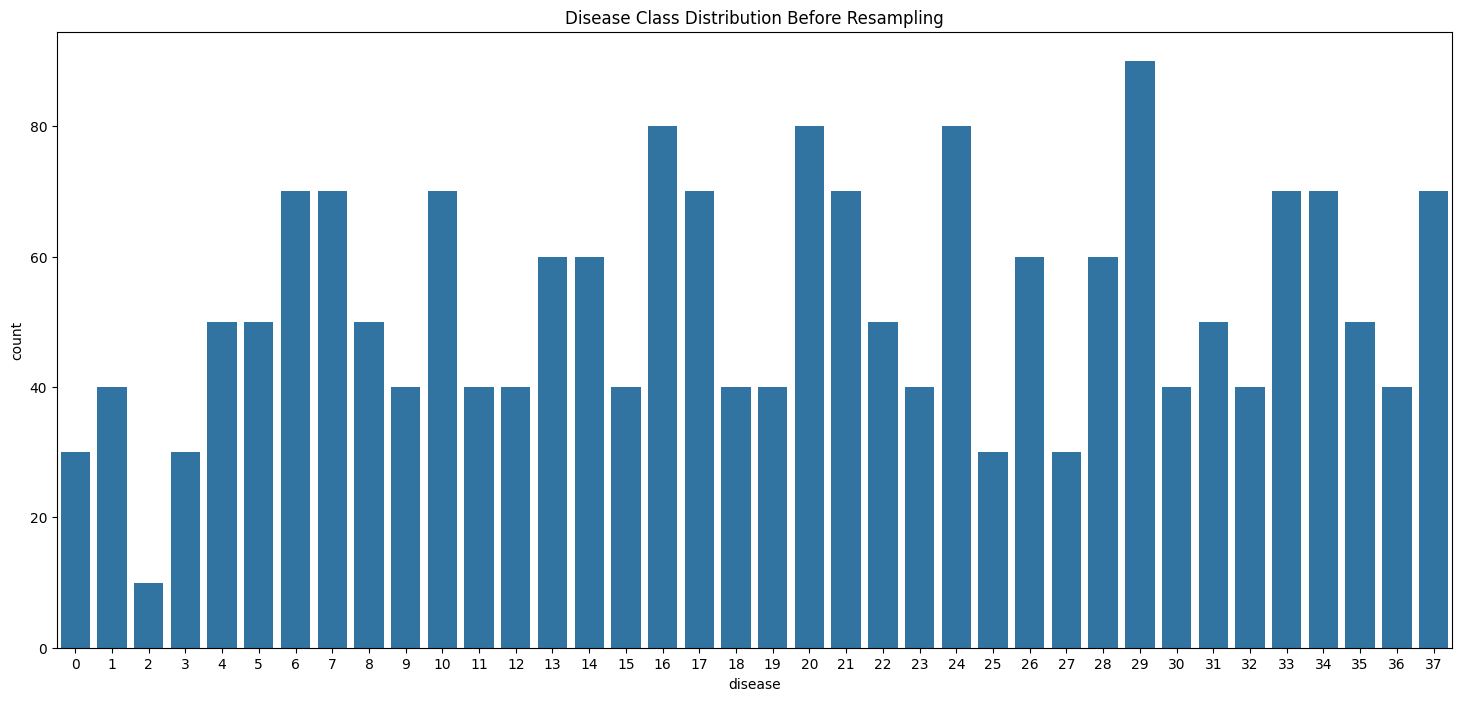

In [13]:
plt.figure(figsize=(18, 8))
sns.countplot(x=y)
plt.title("Disease Class Distribution Before Resampling")
plt.xticks(rotation=0)
plt.show()

In [17]:
y.shape

(2000,)

In [18]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

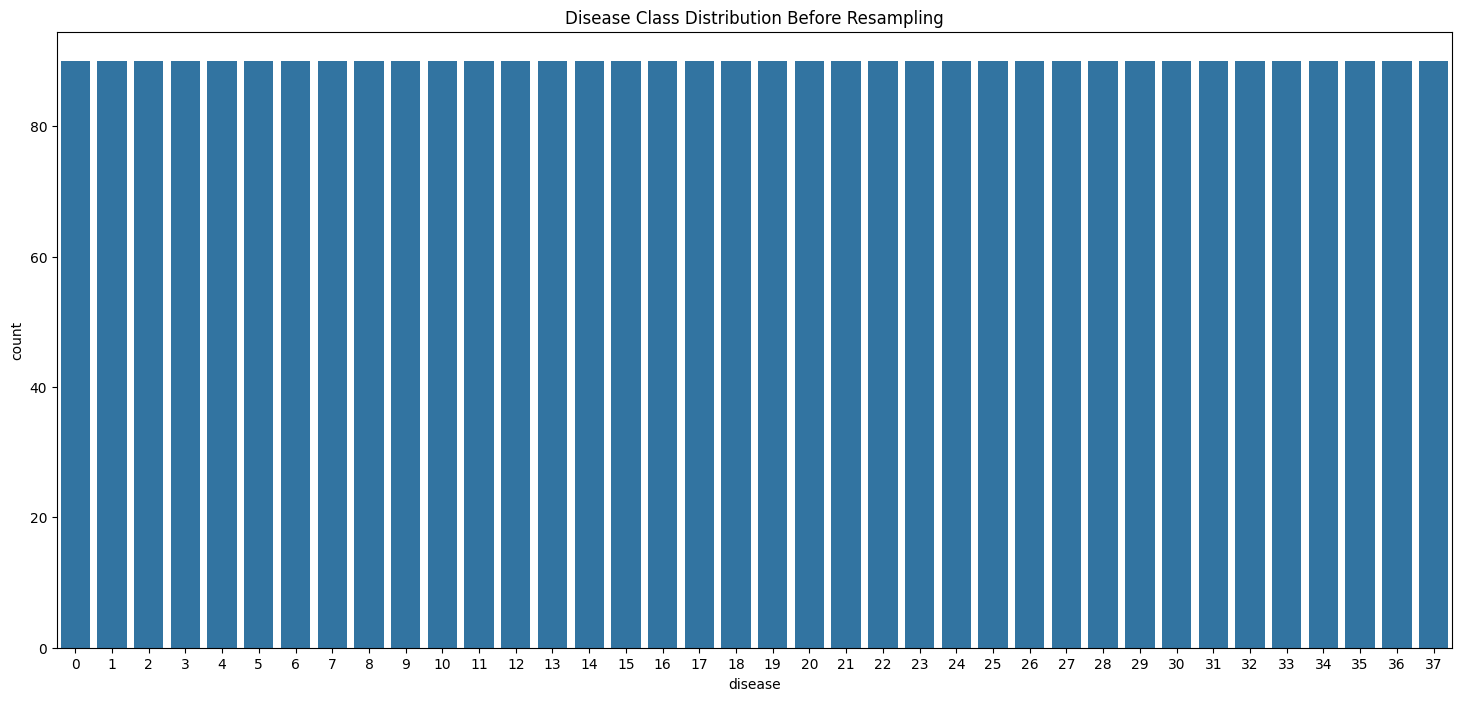

In [19]:
plt.figure(figsize=(18, 8))
sns.countplot(x=y_resampled)
plt.title("Disease Class Distribution Before Resampling")
plt.xticks(rotation=0)
plt.show()

In [20]:
df.head()

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes,disease
0,1,0,1,0,1,0,0,1,1,0,29
1,0,0,1,0,0,0,1,1,0,0,29
2,0,0,1,0,1,0,1,1,0,0,29
3,0,0,1,1,1,0,1,1,1,1,29
4,1,0,1,0,1,0,0,0,1,1,29


3. Train Test Split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

### 4. Buld and Fit the Models

In [23]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

models = [
    SVC(), GaussianNB(), DecisionTreeClassifier(), RandomForestClassifier()
]

for model in range(len(models)):
    models[model].fit(X_train, y_train)
    print(f"{models[model].__class__.__name__}")
    train_pred = models[model].predict(X_train)
    train_accuracy = accuracy_score(y_train, train_pred)
    print(f"Accuracy: {train_accuracy:.3f}")
    print()

SVC
Accuracy: 0.604

GaussianNB
Accuracy: 0.205

DecisionTreeClassifier
Accuracy: 0.707

RandomForestClassifier
Accuracy: 0.707



### 5. Make Prediction

In [25]:
for model in range(len(models)):
    models[model].fit(X_train, y_train)
    print(f"{models[model].__class__.__name__}")
    test_pred = models[model].predict(X_test)
    test_accuracy = accuracy_score(y_test, test_pred)
    print(f"Accuracy: {test_accuracy:.3f}")
    print()

SVC
Accuracy: 0.490

GaussianNB
Accuracy: 0.162

DecisionTreeClassifier
Accuracy: 0.522

RandomForestClassifier
Accuracy: 0.538



### 6. Evaluate the Models

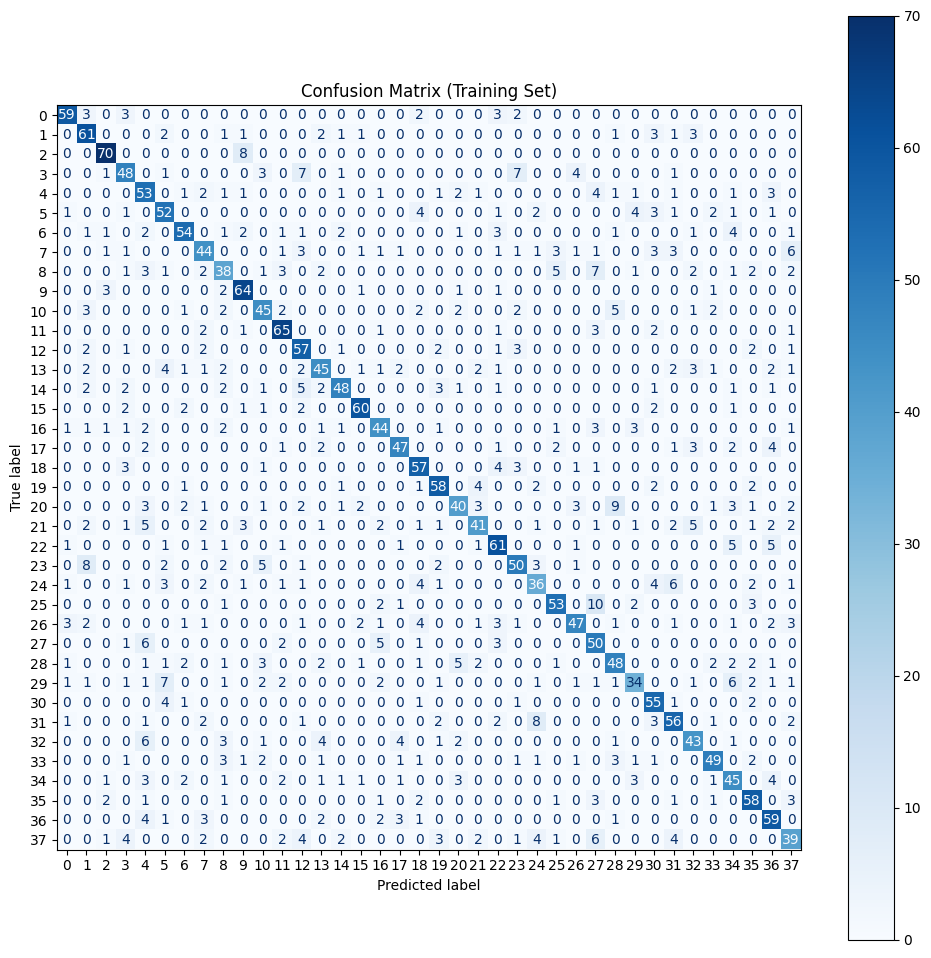

In [32]:
cm_train = confusion_matrix(y_train, train_pred)
fig, ax = plt.subplots(figsize=(12, 12))  # 🔥 control size here
ConfusionMatrixDisplay(confusion_matrix=cm_train).plot(
    cmap='Blues',
    ax=ax
)
plt.title("Confusion Matrix (Training Set)")
plt.show()


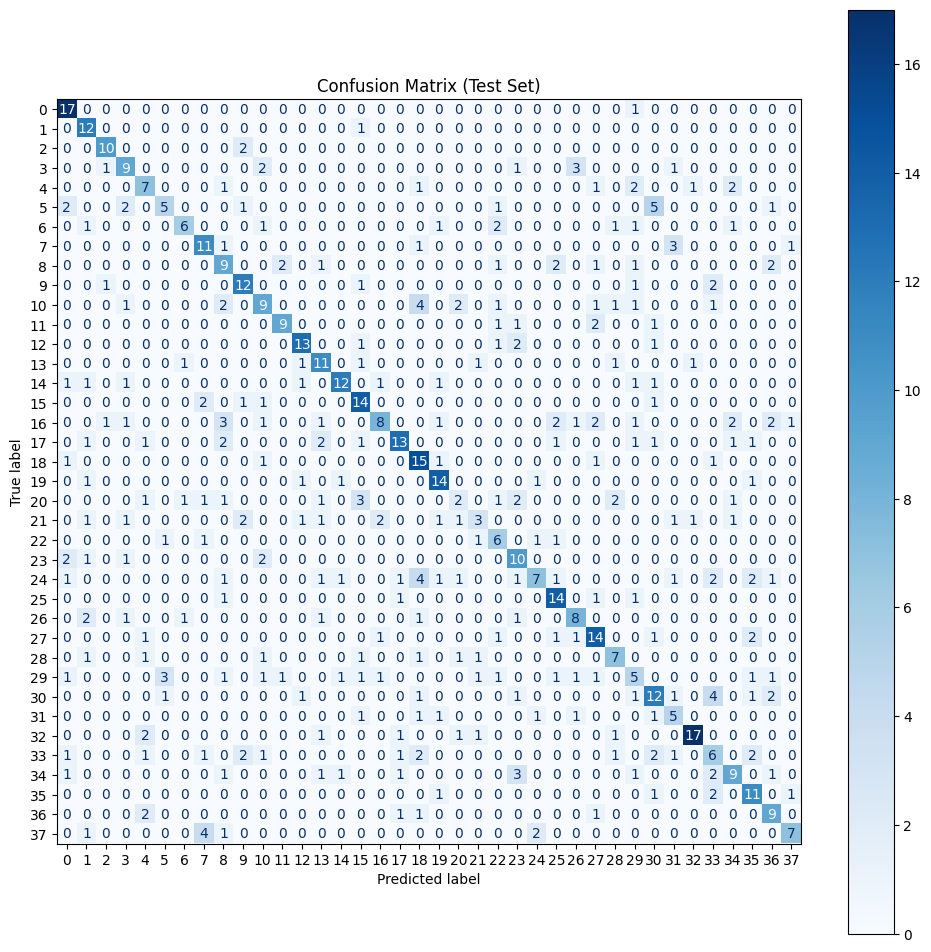

In [31]:
cm_test = confusion_matrix(y_test, test_pred)

fig, ax = plt.subplots(figsize=(12, 12))  # 🔥 control size here
ConfusionMatrixDisplay(confusion_matrix=cm_test).plot(
    cmap='Blues',
    ax=ax
)

plt.title("Confusion Matrix (Test Set)")
plt.show()


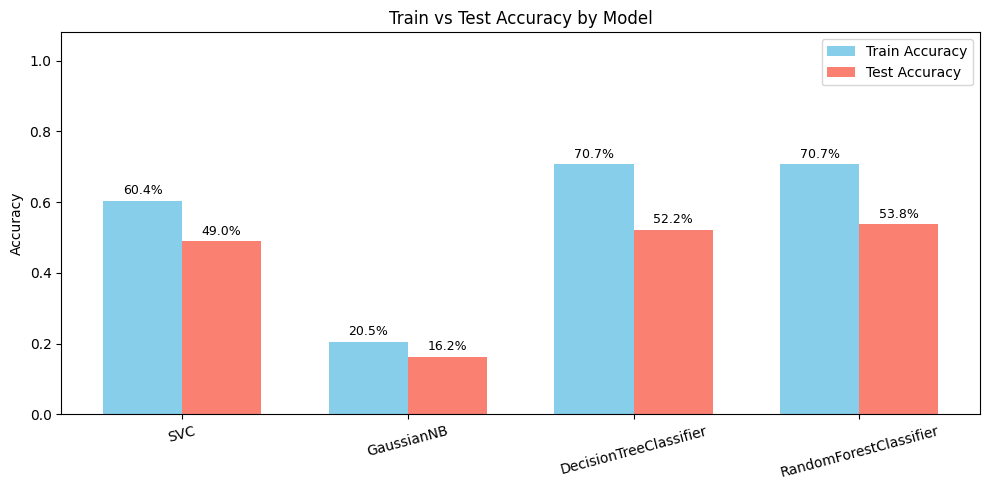

In [34]:
# Bar plot for train and test accuracy of each model
model_names = [model.__class__.__name__ for model in models]
train_accuracies = [accuracy_score(y_train, model.predict(X_train)) for model in models]
test_accuracies = [accuracy_score(y_test, model.predict(X_test)) for model in models]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10, 5))
train_bars = plt.bar(x - width / 2, train_accuracies, width, label='Train Accuracy', color='skyblue')
test_bars = plt.bar(x + width / 2, test_accuracies, width, label='Test Accuracy', color='salmon')

# Add percentage labels on top of each bar
for bar in list(train_bars) + list(test_bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height * 100:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks(x, model_names, rotation=15)
plt.ylim(0, 1.08)
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy by Model')
plt.legend()
plt.tight_layout()
plt.show()